In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/gpr_fwi_diffusion'
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())
print("Files in Drive:", os.listdir(PROJECT_DIR))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/gpr_fwi_diffusion
Files in Drive: ['groundtruth.png', 'observed_data.png', 'obs_data.npy', 'trace_cols.npy', 'gpr_synthetic_dataset.pt', 'loss_history.pt', 'diffusion_unet_weights.pt', 'loss_curves.npy', 'all_metrics.npy', 'inversion_results.npy', 'obs_data_hard.npy', 'trace_cols_hard.npy', 'inversion_results_hard.npy', 'all_metrics_hard.npy', 'figure5_comparison_preview.png', 'obs_data_v2.npy', 'trace_cols_v2.npy', 'all_metrics_v2.npy', 'inversion_results_v2.npy', 'obs_data_v3.npy', 'trace_cols_v3.npy', 'eps_true.npy', 'sig_true.npy', 'figure5_comparison_v3.png', 'inversion_results_v3.npy', 'figure5_comparison_400iter.png', 'all_metrics_v3.npy', 'figure5_final.png', 'eps_dry.npy', 'sig_dry.npy', 'eps_water.npy', 'sig_water.npy', 'eps_napl.npy', 'sig_napl.npy', 'obs_dry.npy', 'tc_dry.npy', 'obs_water.npy', 'tc_water.npy', 'obs_napl.npy', 'tc_napl.npy', 'eps_rec_dry.npy', 'sig_rec_dry.npy', 'eps_rec_water.npy', 'sig_rec

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

EPS_MIN, EPS_MAX = 2.0, 25.0
SIG_MIN, SIG_MAX = 0.0001, 0.05

def normalize(x, lo, hi):
    return 2 * (np.clip(x, lo, hi) - lo) / (hi - lo) - 1

def denormalize(x, lo, hi):
    return (x + 1) / 2 * (hi - lo) + lo

def gaussian_random_field(shape, scale=10.0, seed=None):
    rng = np.random.default_rng(seed)
    noise = rng.normal(size=shape)
    fy = np.fft.fftfreq(shape[0])[:, None]
    fx = np.fft.fftfreq(shape[1])[None, :]
    freq_radius = np.sqrt(fx**2 + fy**2)
    freq_radius[0, 0] = 1e-6
    filt = 1.0 / (1.0 + (freq_radius * scale) ** 2)
    field = np.fft.ifft2(np.fft.fft2(noise) * filt).real
    field -= field.mean()
    field /= field.std() + 1e-8
    return field

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_ch=2, base_ch=64, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim), nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim))
        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)
        self.down1 = ResidualBlock(base_ch, base_ch, time_emb_dim)
        self.pool1 = nn.Conv2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.down2 = ResidualBlock(base_ch, base_ch*2, time_emb_dim)
        self.pool2 = nn.Conv2d(base_ch*2, base_ch*2, 4, stride=2, padding=1)
        self.down3 = ResidualBlock(base_ch*2, base_ch*4, time_emb_dim)
        self.pool3 = nn.Conv2d(base_ch*4, base_ch*4, 4, stride=2, padding=1)
        self.bottleneck = ResidualBlock(base_ch*4, base_ch*4, time_emb_dim)
        self.up3 = nn.ConvTranspose2d(base_ch*4, base_ch*4, 4, stride=2, padding=1)
        self.dec3 = ResidualBlock(base_ch*8, base_ch*2, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(base_ch*2, base_ch*2, 4, stride=2, padding=1)
        self.dec2 = ResidualBlock(base_ch*4, base_ch, time_emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.dec1 = ResidualBlock(base_ch*2, base_ch, time_emb_dim)
        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch), nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, 3, padding=1))
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x0 = self.in_conv(x)
        d1 = self.down1(x0, t_emb)
        d2 = self.down2(self.pool1(d1), t_emb)
        d3 = self.down3(self.pool2(d2), t_emb)
        b  = self.bottleneck(self.pool3(d3), t_emb)
        u3 = self.dec3(torch.cat([self.up3(b),  d3], dim=1), t_emb)
        u2 = self.dec2(torch.cat([self.up2(u3), d2], dim=1), t_emb)
        u1 = self.dec1(torch.cat([self.up1(u2), d1], dim=1), t_emb)
        return self.out_conv(u1)

class DiffusionSchedule:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac   = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_omac = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x0 + sqrt_omac * noise

model    = SimpleUNet().to(device)
schedule = DiffusionSchedule(timesteps=1000, device=device)
model.load_state_dict(torch.load('diffusion_unet_weights.pt', map_location=device))
model.eval()
print("Diffusion model loaded.")

def forward_model(eps, sig, n_traces=32, noise_level=0.0):
    H, W = eps.shape
    t = np.linspace(-1, 1, 21)
    f0 = 0.3
    wavelet    = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    trace_cols = np.linspace(0, W-1, n_traces, dtype=int)
    data       = np.zeros((n_traces, H), dtype=np.float32)
    for i, col in enumerate(trace_cols):
        impedance   = 1.0 / np.sqrt(eps[:, col])
        refl        = np.diff(impedance, prepend=impedance[0])
        attenuation = np.exp(-np.cumsum(sig[:, col]) * 2.0)
        data[i]     = np.convolve(refl * attenuation, wavelet, mode='same')
    if noise_level > 0:
        data += noise_level * np.std(data) * np.random.randn(*data.shape)
    return data.astype(np.float32), trace_cols

def compute_gradient(eps, sig, obs_data, trace_cols):
    H, W      = eps.shape
    t         = np.linspace(-1, 1, 21)
    f0        = 0.3
    wavelet   = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    pred_data = forward_model(eps, sig, n_traces=len(trace_cols))[0]
    residual  = pred_data - obs_data
    misfit    = 0.5 * np.sum(residual**2)
    grad_eps  = np.zeros_like(eps)
    grad_sig  = np.zeros_like(sig)
    for i, col in enumerate(trace_cols):
        adj         = np.convolve(residual[i], wavelet[::-1], mode='same')
        attenuation = np.exp(-np.cumsum(sig[:, col]) * 2.0)
        d_imp_d_eps = -0.5 / (eps[:, col]**1.5)
        for d in range(H):
            grad_eps[d, col] += adj[d] * attenuation[d] * d_imp_d_eps[d]
        for d in range(H):
            grad_sig[d, col] += -2.0 * adj[d] * attenuation[d] * \
                                  np.sum(adj[:d+1])
    return grad_eps, grad_sig, misfit

@torch.no_grad()
def diffusion_project_gentle(eps_arr, sig_arr, t_start=50):
    eps_n = normalize(eps_arr, EPS_MIN, EPS_MAX)
    sig_n = normalize(sig_arr, SIG_MIN, SIG_MAX)
    x0    = torch.from_numpy(
        np.stack([eps_n, sig_n], axis=0)[None]).float().to(device)
    t_tensor = torch.tensor([t_start], device=device)
    x        = schedule.q_sample(x0, t_tensor, torch.randn_like(x0))
    for t_cur in reversed(range(0, t_start)):
        t_cur_tensor = torch.tensor([t_cur], device=device)
        beta_t    = schedule.betas[t_cur]
        alpha_t   = schedule.alphas[t_cur]
        alpha_bar = schedule.alphas_cumprod[t_cur]
        pred_noise = model(x, t_cur_tensor)
        if t_cur > 0:
            coef = beta_t / torch.sqrt(1 - alpha_bar)
            x    = (1 / torch.sqrt(alpha_t)) * (x - coef * pred_noise)
        else:
            x = (x - torch.sqrt(1 - alpha_bar) * pred_noise) / \
                 torch.sqrt(alpha_bar)
            x = torch.clamp(x, -1, 1)
    x_d     = x.squeeze(0).cpu().numpy()
    eps_den = np.clip(denormalize(x_d[0], EPS_MIN, EPS_MAX), EPS_MIN, EPS_MAX)
    sig_den = np.clip(denormalize(x_d[1], SIG_MIN, SIG_MAX), SIG_MIN, SIG_MAX)
    return eps_den, sig_den

from skimage.metrics import structural_similarity as skssim
def compute_metrics(recon, true):
    rmse     = np.sqrt(np.mean((recon - true)**2))
    ssim_val = skssim(true, recon, data_range=true.max() - true.min())
    return rmse, ssim_val

print("All definitions ready.")

Device: cuda
Diffusion model loaded.
All definitions ready.


eps_r range: 5.77 - 20.00
sigma range: 0.00407 - 0.02000
Conduit pixels: 584


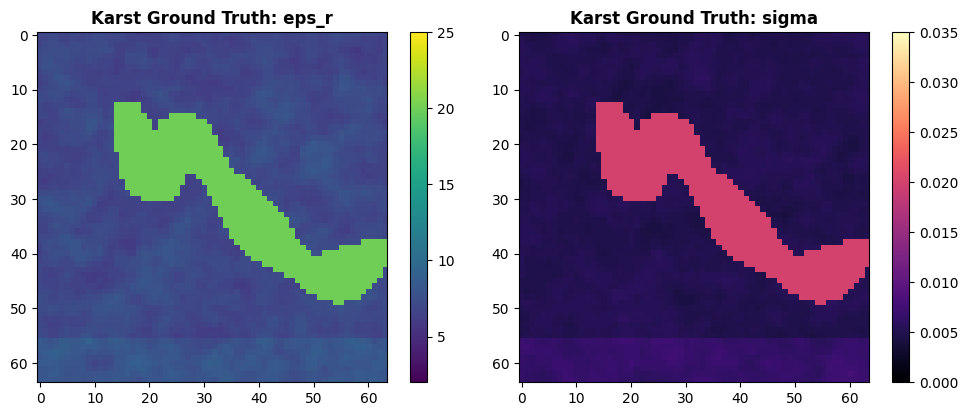

Karst ground truth saved to Drive.


In [4]:
np.random.seed(7)
H, W = 64, 64

# ---- Karst host rock background (limestone) ----
eps_karst = 7.0 * (1 + 0.06 * gaussian_random_field((H, W), scale=10.0, seed=7))
sig_karst = 0.005 * (1 + 0.06 * gaussian_random_field((H, W), scale=10.0, seed=8))
eps_karst = eps_karst.astype(np.float32)
sig_karst = sig_karst.astype(np.float32)

# Slightly denser deep limestone zone (no concrete floor in karst setting)
eps_karst[56:, :] *= 1.15
sig_karst[56:, :] *= 1.3

# ---- Elongated, curving water-filled conduit ----
def make_conduit_mask(shape, seed=42):
    H, W = shape
    t = np.linspace(0, 1, 200)
    path_row = 15 + 25 * t + 8 * np.sin(3 * np.pi * t)
    path_col = 10 + 45 * t + 6 * np.cos(2 * np.pi * t)
    width    = 3 + 2 * np.sin(5 * np.pi * t) ** 2

    mask = np.zeros(shape, dtype=bool)
    yy, xx = np.mgrid[0:H, 0:W]
    for pr, pc, w in zip(path_row, path_col, width):
        dist = np.sqrt((yy - pr) ** 2 + (xx - pc) ** 2)
        mask |= (dist < w)
    return mask

conduit_mask = make_conduit_mask((H, W), seed=42)
conduit_mask[56:, :] = False

eps_karst[conduit_mask] = 20.0
sig_karst[conduit_mask] = 0.02

print(f"eps_r range: {eps_karst.min():.2f} - {eps_karst.max():.2f}")
print(f"sigma range: {sig_karst.min():.5f} - {sig_karst.max():.5f}")
print(f"Conduit pixels: {conduit_mask.sum()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(eps_karst, cmap='viridis', vmin=2, vmax=25)
axes[0].set_title('Karst Ground Truth: eps_r', fontweight='bold')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(sig_karst, cmap='magma', vmin=0, vmax=0.035)
axes[1].set_title('Karst Ground Truth: sigma', fontweight='bold')
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

np.save('eps_karst.npy', eps_karst)
np.save('sig_karst.npy', sig_karst)
print("Karst ground truth saved to Drive.")

Karst data shape: (32, 64)
Data range: -0.1691 to 0.1297


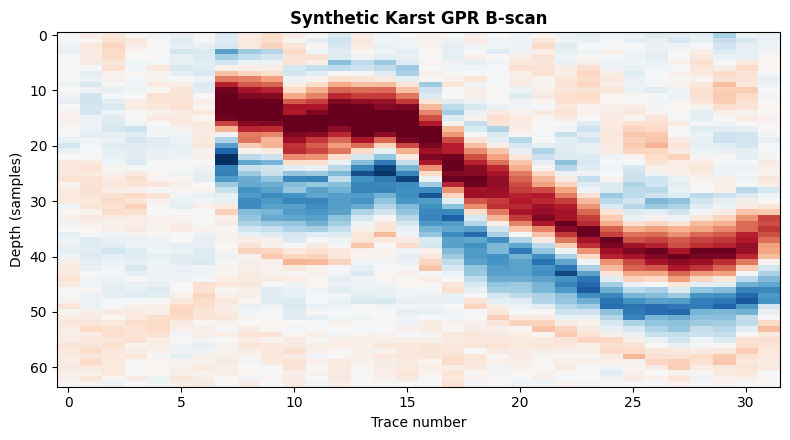

Karst observed data saved to Drive.


In [5]:
np.random.seed(42)
obs_karst, tc_karst = forward_model(eps_karst, sig_karst,
                                     n_traces=32, noise_level=0.10)

print(f"Karst data shape: {obs_karst.shape}")
print(f"Data range: {obs_karst.min():.4f} to {obs_karst.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
vmax = np.percentile(np.abs(obs_karst), 98)
ax.imshow(obs_karst.T, cmap='RdBu', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Trace number')
ax.set_ylabel('Depth (samples)')
ax.set_title('Synthetic Karst GPR B-scan', fontweight='bold')
plt.tight_layout()
plt.show()

np.save('obs_karst.npy', obs_karst)
np.save('tc_karst.npy', tc_karst)
print("Karst observed data saved to Drive.")

In [6]:
def laplacian_gradient(x):
    lap = (np.roll(x, 1, axis=0) + np.roll(x, -1, axis=0) +
           np.roll(x, 1, axis=1) + np.roll(x, -1, axis=1) - 4*x)
    return -lap

def tv_gradient(x, eps_tv=1e-3):
    dx = np.diff(x, axis=1, append=x[:, -1:])
    dy = np.diff(x, axis=0, append=x[-1:, :])
    norm = np.sqrt(dx**2 + dy**2 + eps_tv**2)
    px, py = dx / norm, dy / norm
    div = (np.diff(px, axis=1, prepend=px[:, :1]) +
           np.diff(py, axis=0, prepend=py[:1, :]))
    return -div

eps_init_karst = 7.0 * np.ones((64, 64), dtype=np.float32)
sig_init_karst = 0.005 * np.ones((64, 64), dtype=np.float32)
eps_init_karst[56:, :] *= 1.15
sig_init_karst[56:, :] *= 1.3

N_ITER = 200
N_ITER_DIFF = 400
LR_EPS, LR_SIG = 0.05, 0.0001
LAMBDA_TIK, LAMBDA_TV, BLEND = 0.01, 0.05, 0.08

results_karst = {}
metrics_karst = {}

# Method 1: No Reg
print("Running Method 1: No regularization...")
eps, sig = eps_init_karst.copy(), sig_init_karst.copy()
for it in range(N_ITER):
    ge, gs, _ = compute_gradient(eps, sig, obs_karst, tc_karst)
    eps = np.clip(eps - LR_EPS*ge, EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG*gs, SIG_MIN, SIG_MAX)
results_karst['No Reg'] = (eps.copy(), sig.copy())
re, se = compute_metrics(eps, eps_karst); rs, ss = compute_metrics(sig, sig_karst)
metrics_karst['No Reg'] = {'eps_rmse': re, 'eps_ssim': se, 'sig_rmse': rs, 'sig_ssim': ss}
print(f"  eps_r RMSE={re:.4f} SSIM={se:.4f} | sigma RMSE={rs:.6f} SSIM={ss:.4f}")

# Method 2: Tikhonov
print("Running Method 2: Tikhonov...")
eps, sig = eps_init_karst.copy(), sig_init_karst.copy()
for it in range(N_ITER):
    ge, gs, _ = compute_gradient(eps, sig, obs_karst, tc_karst)
    eps = np.clip(eps - LR_EPS*(ge + LAMBDA_TIK*laplacian_gradient(eps)), EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG*(gs + LAMBDA_TIK*laplacian_gradient(sig)), SIG_MIN, SIG_MAX)
results_karst['Tikhonov'] = (eps.copy(), sig.copy())
re, se = compute_metrics(eps, eps_karst); rs, ss = compute_metrics(sig, sig_karst)
metrics_karst['Tikhonov'] = {'eps_rmse': re, 'eps_ssim': se, 'sig_rmse': rs, 'sig_ssim': ss}
print(f"  eps_r RMSE={re:.4f} SSIM={se:.4f} | sigma RMSE={rs:.6f} SSIM={ss:.4f}")

# Method 3: TV
print("Running Method 3: TV...")
eps, sig = eps_init_karst.copy(), sig_init_karst.copy()
for it in range(N_ITER):
    ge, gs, _ = compute_gradient(eps, sig, obs_karst, tc_karst)
    eps = np.clip(eps - LR_EPS*(ge + LAMBDA_TV*tv_gradient(eps)), EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG*(gs + LAMBDA_TV*tv_gradient(sig)), SIG_MIN, SIG_MAX)
results_karst['TV'] = (eps.copy(), sig.copy())
re, se = compute_metrics(eps, eps_karst); rs, ss = compute_metrics(sig, sig_karst)
metrics_karst['TV'] = {'eps_rmse': re, 'eps_ssim': se, 'sig_rmse': rs, 'sig_ssim': ss}
print(f"  eps_r RMSE={re:.4f} SSIM={se:.4f} | sigma RMSE={rs:.6f} SSIM={ss:.4f}")

# Method 4: Diffusion Prior (unmodified, trained only on tank data)
print("Running Method 4: Diffusion Prior...")
eps, sig = eps_init_karst.copy(), sig_init_karst.copy()
for it in range(N_ITER_DIFF):
    ge, gs, misfit = compute_gradient(eps, sig, obs_karst, tc_karst)
    eps = np.clip(eps - LR_EPS*ge, EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG*gs, SIG_MIN, SIG_MAX)
    if it % 5 == 0:
        eps_den, sig_den = diffusion_project_gentle(eps, sig, t_start=50)
        eps = np.clip((1-BLEND)*eps + BLEND*eps_den, EPS_MIN, EPS_MAX)
        sig = np.clip((1-BLEND)*sig + BLEND*sig_den, SIG_MIN, SIG_MAX)
    if (it+1) % 100 == 0:
        print(f"  iter {it+1}/{N_ITER_DIFF}, misfit={misfit:.4f}")
results_karst['Diffusion'] = (eps.copy(), sig.copy())
re, se = compute_metrics(eps, eps_karst); rs, ss = compute_metrics(sig, sig_karst)
metrics_karst['Diffusion'] = {'eps_rmse': re, 'eps_ssim': se, 'sig_rmse': rs, 'sig_ssim': ss}
print(f"  eps_r RMSE={re:.4f} SSIM={se:.4f} | sigma RMSE={rs:.6f} SSIM={ss:.4f}")

np.save('results_karst.npy', results_karst, allow_pickle=True)
np.save('metrics_karst.npy', metrics_karst, allow_pickle=True)
print("\nAll karst inversion results saved to Drive.")

Running Method 1: No regularization...
  eps_r RMSE=4.9193 SSIM=0.4323 | sigma RMSE=0.009684 SSIM=0.1920
Running Method 2: Tikhonov...
  eps_r RMSE=4.9195 SSIM=0.4309 | sigma RMSE=0.009722 SSIM=0.1905
Running Method 3: TV...
  eps_r RMSE=4.9194 SSIM=0.4295 | sigma RMSE=0.009605 SSIM=0.2674
Running Method 4: Diffusion Prior...
  iter 100/400, misfit=1.5696
  iter 200/400, misfit=1.5947
  iter 300/400, misfit=1.6979
  iter 400/400, misfit=1.7976
  eps_r RMSE=5.2916 SSIM=0.3591 | sigma RMSE=0.007251 SSIM=0.2097

All karst inversion results saved to Drive.


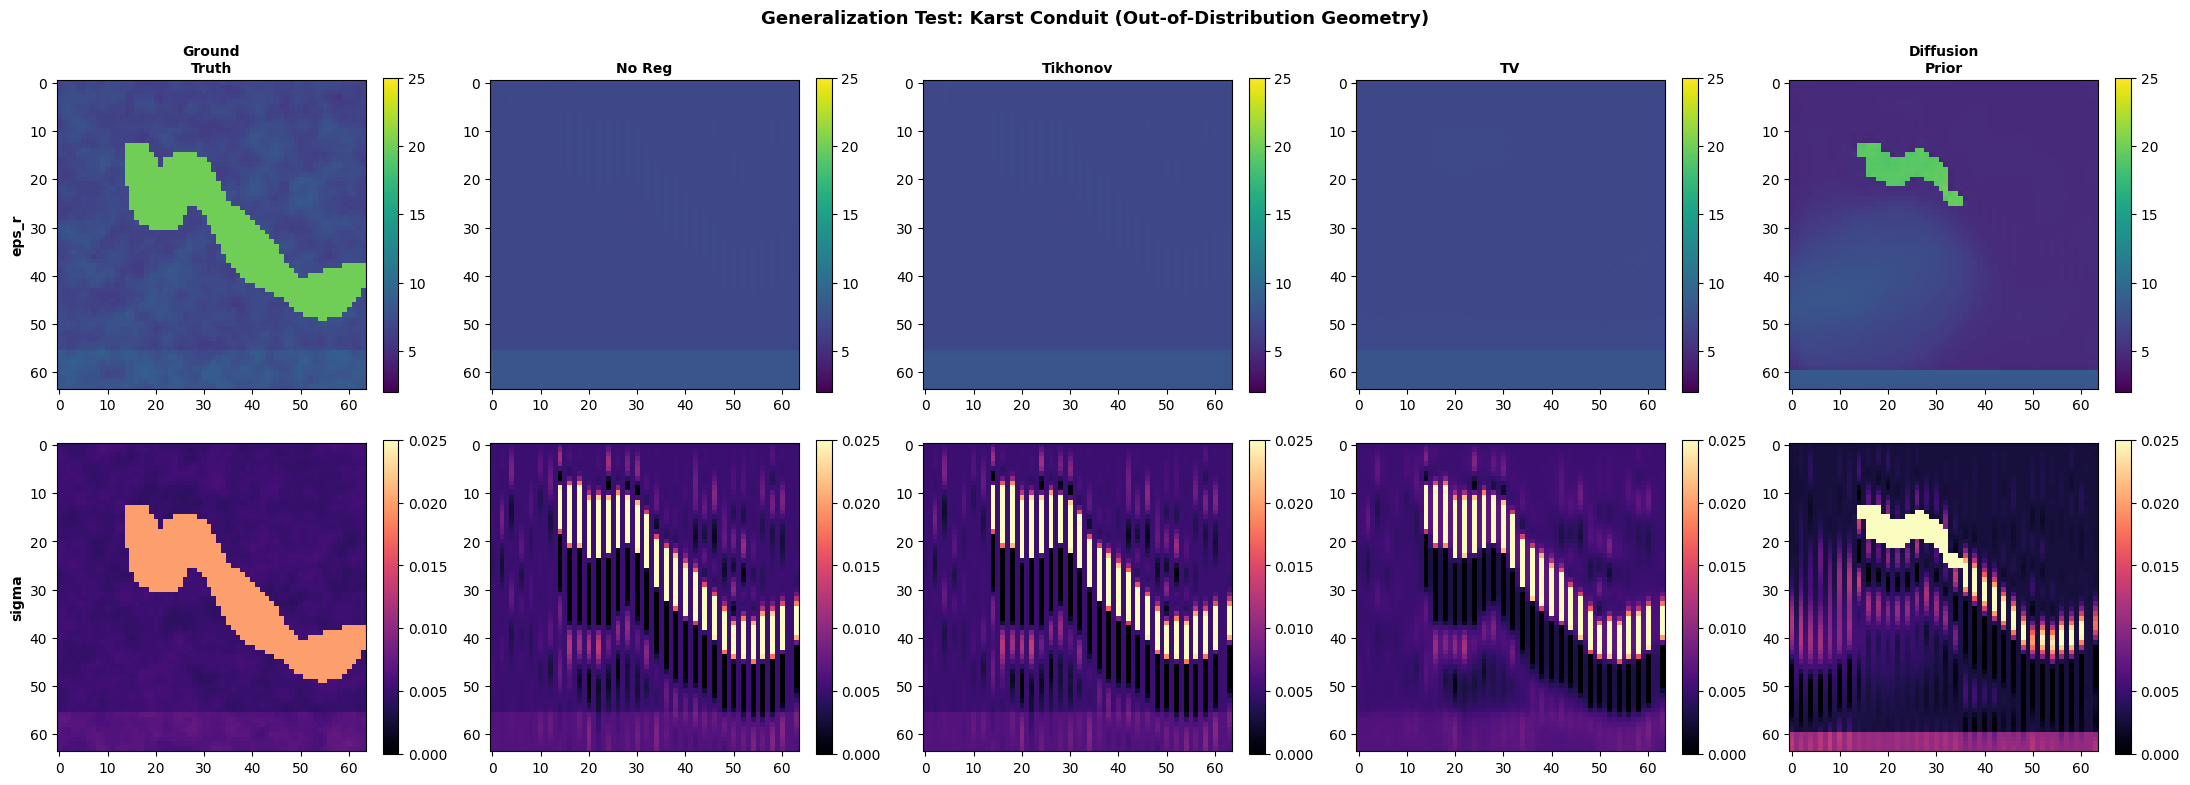

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
cols = ['Ground\nTruth', 'No Reg', 'Tikhonov', 'TV', 'Diffusion\nPrior']
eps_arrays = [eps_karst,
              results_karst['No Reg'][0], results_karst['Tikhonov'][0],
              results_karst['TV'][0],     results_karst['Diffusion'][0]]
sig_arrays = [sig_karst,
              results_karst['No Reg'][1], results_karst['Tikhonov'][1],
              results_karst['TV'][1],     results_karst['Diffusion'][1]]

for j in range(5):
    im = axes[0, j].imshow(eps_arrays[j], cmap='viridis', vmin=2, vmax=25)
    axes[0, j].set_title(cols[j], fontsize=10, fontweight='bold')
    if j == 0:
        axes[0, j].set_ylabel('eps_r', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=axes[0, j], fraction=0.046)

for j in range(5):
    im = axes[1, j].imshow(sig_arrays[j], cmap='magma', vmin=0, vmax=0.025)
    if j == 0:
        axes[1, j].set_ylabel('sigma', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=axes[1, j], fraction=0.046)

plt.suptitle('Generalization Test: Karst Conduit (Out-of-Distribution Geometry)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure8_karst_preview.png', dpi=150)
plt.show()

Conduit pixels: 752


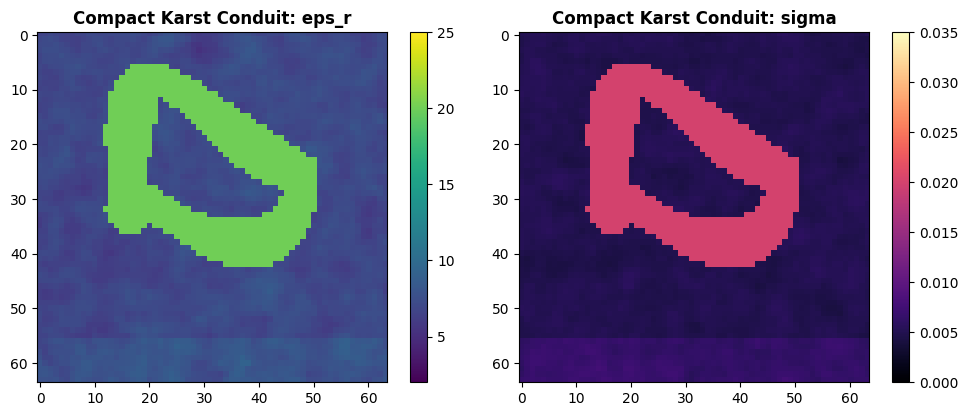

Compact karst ground truth saved.


In [8]:
np.random.seed(15)

def make_compact_conduit_mask(shape, seed=15):
    H, W = shape
    t = np.linspace(0, 1, 200)
    # Tighter, more curved/looping path -- no long straight run
    path_row = 25 + 12 * np.sin(2 * np.pi * t) + 5 * np.sin(5 * np.pi * t)
    path_col = 28 + 16 * np.cos(2 * np.pi * t) + 4 * np.cos(4 * np.pi * t)
    width    = 3 + 1.5 * np.sin(4 * np.pi * t) ** 2

    mask = np.zeros(shape, dtype=bool)
    yy, xx = np.mgrid[0:H, 0:W]
    for pr, pc, w in zip(path_row, path_col, width):
        dist = np.sqrt((yy - pr) ** 2 + (xx - pc) ** 2)
        mask |= (dist < w)
    return mask

eps_karst2 = 7.0 * (1 + 0.06 * gaussian_random_field((64, 64), scale=10.0, seed=15))
sig_karst2 = 0.005 * (1 + 0.06 * gaussian_random_field((64, 64), scale=10.0, seed=16))
eps_karst2 = eps_karst2.astype(np.float32)
sig_karst2 = sig_karst2.astype(np.float32)
eps_karst2[56:, :] *= 1.15
sig_karst2[56:, :] *= 1.3

conduit_mask2 = make_compact_conduit_mask((64, 64), seed=15)
conduit_mask2[56:, :] = False
eps_karst2[conduit_mask2] = 20.0
sig_karst2[conduit_mask2] = 0.02

print(f"Conduit pixels: {conduit_mask2.sum()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(eps_karst2, cmap='viridis', vmin=2, vmax=25)
axes[0].set_title('Compact Karst Conduit: eps_r', fontweight='bold')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(sig_karst2, cmap='magma', vmin=0, vmax=0.035)
axes[1].set_title('Compact Karst Conduit: sigma', fontweight='bold')
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

np.save('eps_karst2.npy', eps_karst2)
np.save('sig_karst2.npy', sig_karst2)
print("Compact karst ground truth saved.")

In [9]:
np.random.seed(43)
obs_karst2, tc_karst2 = forward_model(eps_karst2, sig_karst2,
                                       n_traces=32, noise_level=0.10)
np.save('obs_karst2.npy', obs_karst2)
np.save('tc_karst2.npy', tc_karst2)
print(f"Compact karst data shape: {obs_karst2.shape}, range: "
      f"{obs_karst2.min():.4f} to {obs_karst2.max():.4f}")

eps_init_k2 = 7.0 * np.ones((64, 64), dtype=np.float32)
sig_init_k2 = 0.005 * np.ones((64, 64), dtype=np.float32)
eps_init_k2[56:, :] *= 1.15
sig_init_k2[56:, :] *= 1.3

results_karst2 = {}
metrics_karst2 = {}

# No Reg
eps, sig = eps_init_k2.copy(), sig_init_k2.copy()
print("Running No Reg...")
for it in range(N_ITER):
    ge, gs, _ = compute_gradient(eps, sig, obs_karst2, tc_karst2)
    eps = np.clip(eps - LR_EPS*ge, EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG*gs, SIG_MIN, SIG_MAX)
results_karst2['No Reg'] = (eps.copy(), sig.copy())
re, se = compute_metrics(eps, eps_karst2); rs, ss = compute_metrics(sig, sig_karst2)
metrics_karst2['No Reg'] = {'eps_rmse': re, 'eps_ssim': se, 'sig_rmse': rs, 'sig_ssim': ss}
print(f"  eps_r RMSE={re:.4f} SSIM={se:.4f}")

# Tikhonov
eps, sig = eps_init_k2.copy(), sig_init_k2.copy()
print("Running Tikhonov...")
for it in range(N_ITER):
    ge, gs, _ = compute_gradient(eps, sig, obs_karst2, tc_karst2)
    eps = np.clip(eps - LR_EPS*(ge + LAMBDA_TIK*laplacian_gradient(eps)), EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG*(gs + LAMBDA_TIK*laplacian_gradient(sig)), SIG_MIN, SIG_MAX)
results_karst2['Tikhonov'] = (eps.copy(), sig.copy())
re, se = compute_metrics(eps, eps_karst2); rs, ss = compute_metrics(sig, sig_karst2)
metrics_karst2['Tikhonov'] = {'eps_rmse': re, 'eps_ssim': se, 'sig_rmse': rs, 'sig_ssim': ss}
print(f"  eps_r RMSE={re:.4f} SSIM={se:.4f}")

# TV
eps, sig = eps_init_k2.copy(), sig_init_k2.copy()
print("Running TV...")
for it in range(N_ITER):
    ge, gs, _ = compute_gradient(eps, sig, obs_karst2, tc_karst2)
    eps = np.clip(eps - LR_EPS*(ge + LAMBDA_TV*tv_gradient(eps)), EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG*(gs + LAMBDA_TV*tv_gradient(sig)), SIG_MIN, SIG_MAX)
results_karst2['TV'] = (eps.copy(), sig.copy())
re, se = compute_metrics(eps, eps_karst2); rs, ss = compute_metrics(sig, sig_karst2)
metrics_karst2['TV'] = {'eps_rmse': re, 'eps_ssim': se, 'sig_rmse': rs, 'sig_ssim': ss}
print(f"  eps_r RMSE={re:.4f} SSIM={se:.4f}")

# Diffusion Prior
eps, sig = eps_init_k2.copy(), sig_init_k2.copy()
print("Running Diffusion Prior...")
for it in range(N_ITER_DIFF):
    ge, gs, misfit = compute_gradient(eps, sig, obs_karst2, tc_karst2)
    eps = np.clip(eps - LR_EPS*ge, EPS_MIN, EPS_MAX)
    sig = np.clip(sig - LR_SIG*gs, SIG_MIN, SIG_MAX)
    if it % 5 == 0:
        eps_den, sig_den = diffusion_project_gentle(eps, sig, t_start=50)
        eps = np.clip((1-BLEND)*eps + BLEND*eps_den, EPS_MIN, EPS_MAX)
        sig = np.clip((1-BLEND)*sig + BLEND*sig_den, SIG_MIN, SIG_MAX)
    if (it+1) % 100 == 0:
        print(f"  iter {it+1}/{N_ITER_DIFF}, misfit={misfit:.4f}")
results_karst2['Diffusion'] = (eps.copy(), sig.copy())
re, se = compute_metrics(eps, eps_karst2); rs, ss = compute_metrics(sig, sig_karst2)
metrics_karst2['Diffusion'] = {'eps_rmse': re, 'eps_ssim': se, 'sig_rmse': rs, 'sig_ssim': ss}
print(f"  eps_r RMSE={re:.4f} SSIM={se:.4f}")

np.save('results_karst2.npy', results_karst2, allow_pickle=True)
np.save('metrics_karst2.npy', metrics_karst2, allow_pickle=True)
print("\nAll compact karst results saved to Drive.")

Compact karst data shape: (32, 64), range: -0.1851 to 0.1430
Running No Reg...
  eps_r RMSE=5.5794 SSIM=0.3819
Running Tikhonov...
  eps_r RMSE=5.5794 SSIM=0.3804
Running TV...
  eps_r RMSE=5.5805 SSIM=0.3803
Running Diffusion Prior...
  iter 100/400, misfit=1.7168
  iter 200/400, misfit=1.8401
  iter 300/400, misfit=2.0311
  iter 400/400, misfit=2.1306
  eps_r RMSE=6.1939 SSIM=0.2944

All compact karst results saved to Drive.


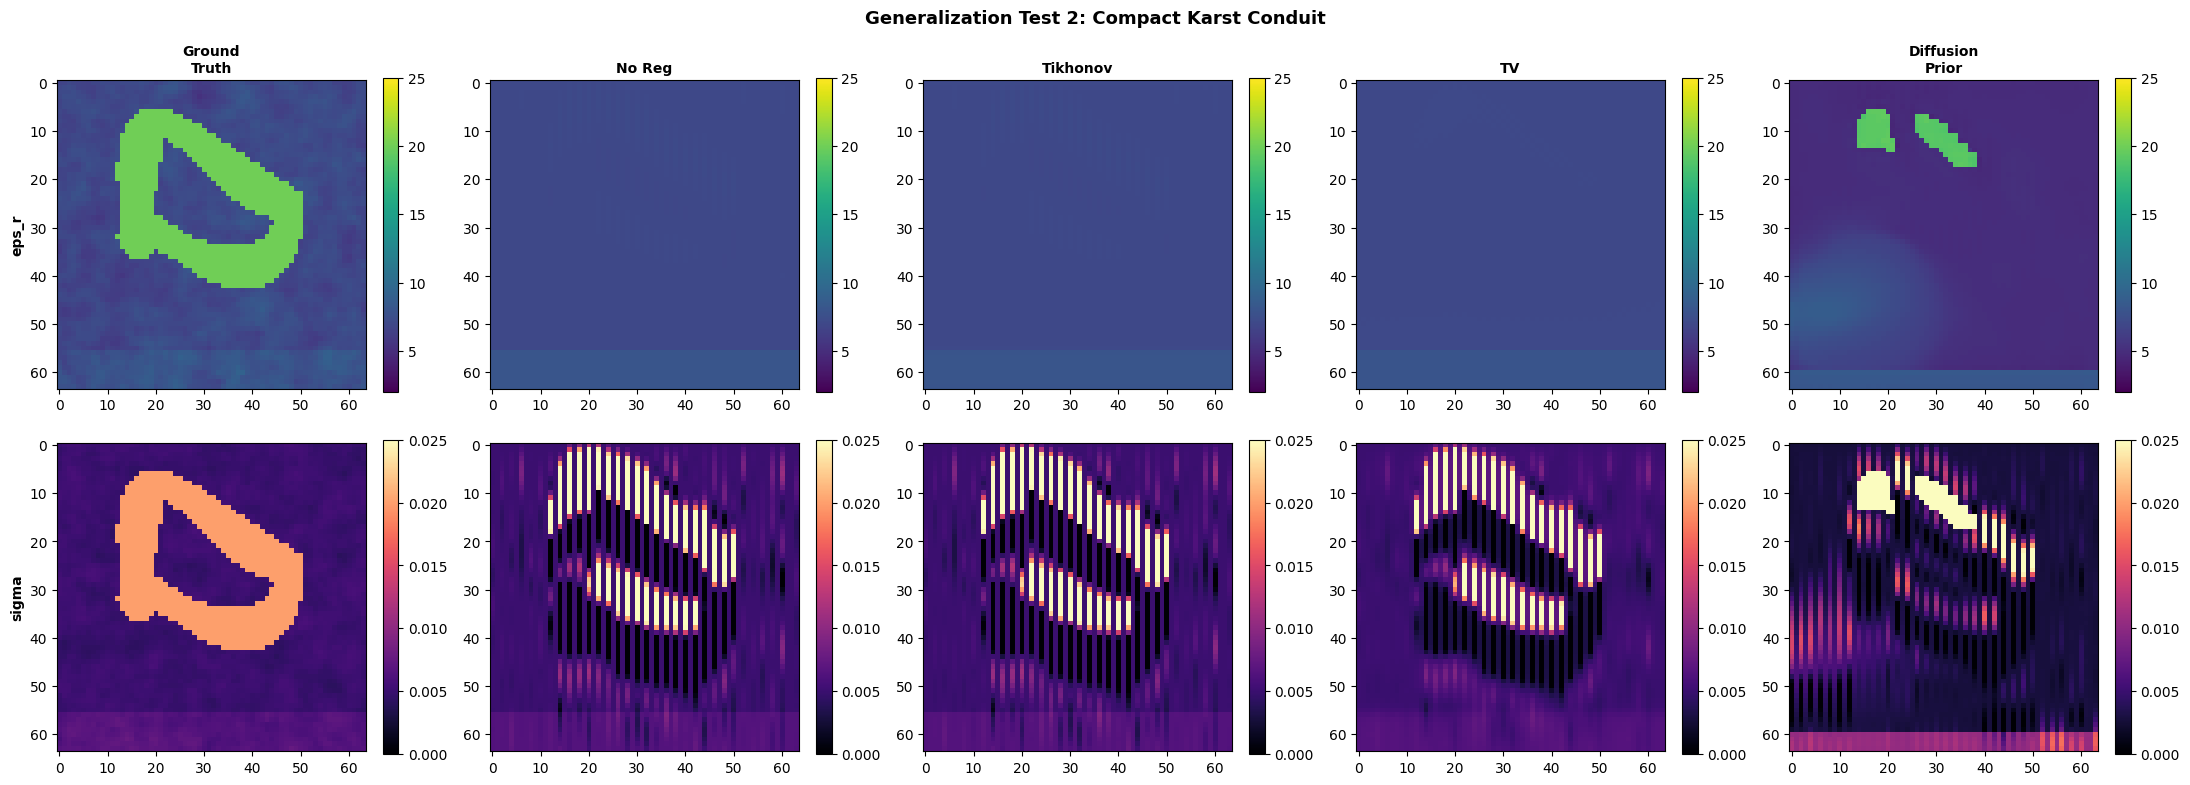

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
cols = ['Ground\nTruth', 'No Reg', 'Tikhonov', 'TV', 'Diffusion\nPrior']
eps_arrays = [eps_karst2,
              results_karst2['No Reg'][0], results_karst2['Tikhonov'][0],
              results_karst2['TV'][0],     results_karst2['Diffusion'][0]]
sig_arrays = [sig_karst2,
              results_karst2['No Reg'][1], results_karst2['Tikhonov'][1],
              results_karst2['TV'][1],     results_karst2['Diffusion'][1]]

for j in range(5):
    im = axes[0, j].imshow(eps_arrays[j], cmap='viridis', vmin=2, vmax=25)
    axes[0, j].set_title(cols[j], fontsize=10, fontweight='bold')
    if j == 0:
        axes[0, j].set_ylabel('eps_r', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=axes[0, j], fraction=0.046)

for j in range(5):
    im = axes[1, j].imshow(sig_arrays[j], cmap='magma', vmin=0, vmax=0.025)
    if j == 0:
        axes[1, j].set_ylabel('sigma', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=axes[1, j], fraction=0.046)

plt.suptitle('Generalization Test 2: Compact Karst Conduit',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure8_karst2_preview.png', dpi=150)
plt.show()

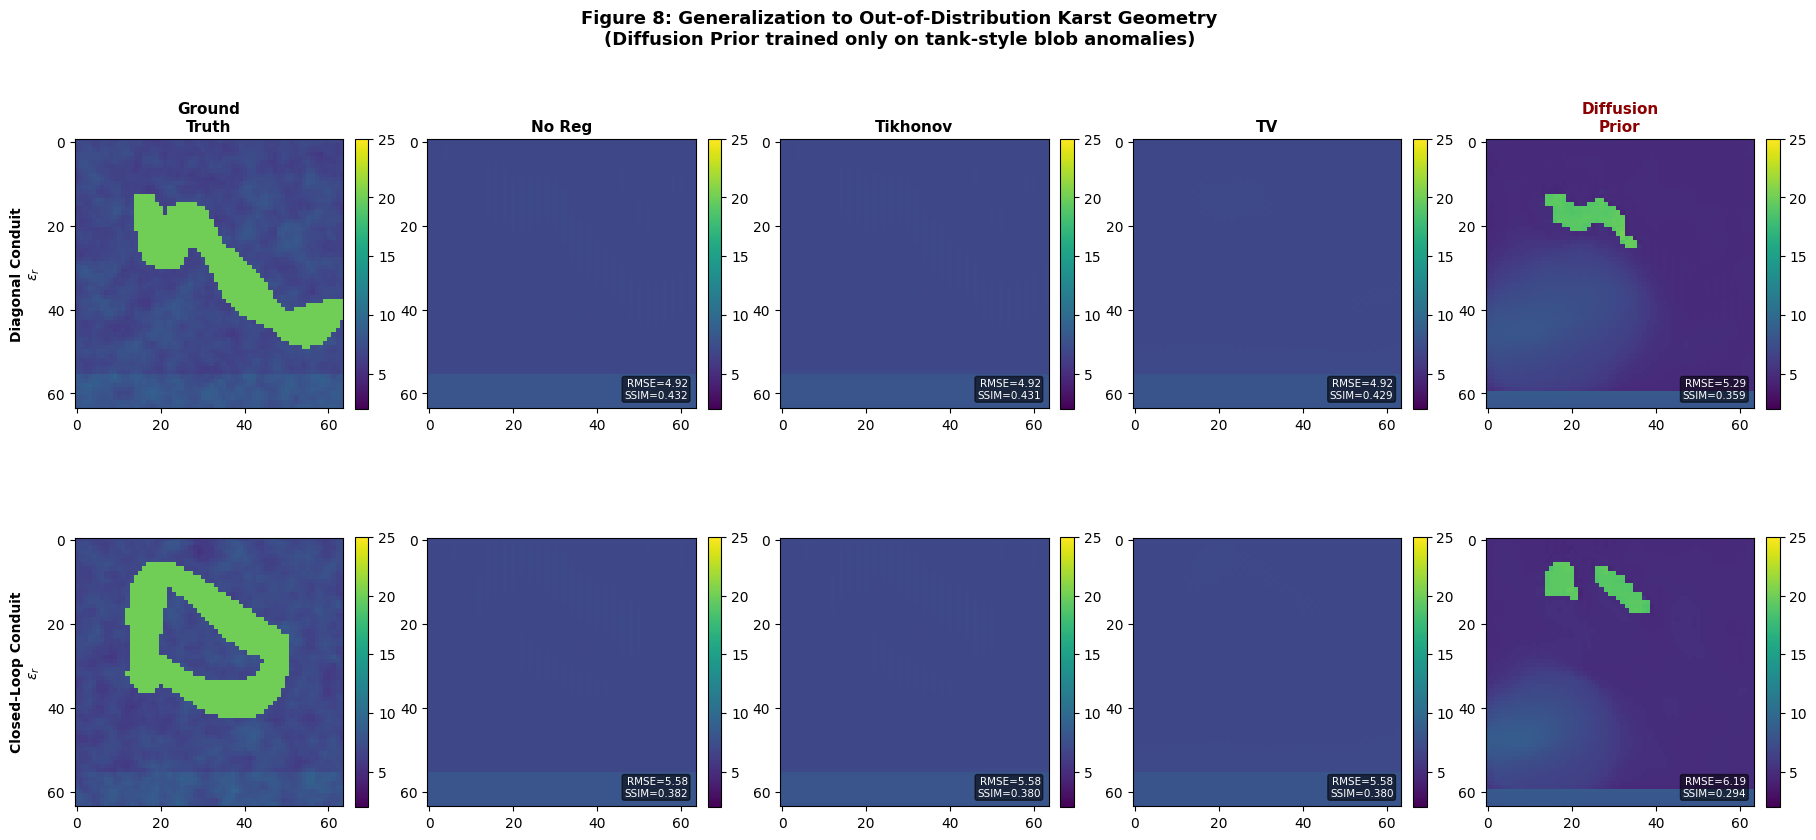

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 8 saved at 300 dpi.


In [11]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(22, 9))
gs  = GridSpec(2, 5, figure=fig, hspace=0.35, wspace=0.2)

cols = ['Ground\nTruth', 'No Reg', 'Tikhonov', 'TV', 'Diffusion\nPrior']

test_data = [
    ('Diagonal Conduit', eps_karst,  results_karst,  metrics_karst),
    ('Closed-Loop Conduit', eps_karst2, results_karst2, metrics_karst2),
]

for i, (test_name, truth, results, metrics) in enumerate(test_data):
    eps_arrays = [truth,
                  results['No Reg'][0], results['Tikhonov'][0],
                  results['TV'][0],     results['Diffusion'][0]]
    eps_metrics = ['']
    for m in ['No Reg', 'Tikhonov', 'TV', 'Diffusion']:
        eps_metrics.append(f"RMSE={metrics[m]['eps_rmse']:.2f}\n"
                           f"SSIM={metrics[m]['eps_ssim']:.3f}")

    for j in range(5):
        ax = fig.add_subplot(gs[i, j])
        im = ax.imshow(eps_arrays[j], cmap='viridis', vmin=2, vmax=25)
        title = cols[j] if i == 0 else ''
        ax.set_title(title, fontsize=11, fontweight='bold',
                     color='#8B0000' if (i == 0 and j == 4) else 'black')
        ax.set_xticks([0, 20, 40, 60])
        ax.set_yticks([0, 20, 40, 60])
        if j == 0:
            ax.set_ylabel(f'{test_name}\n' + r'$\varepsilon_r$',
                          fontsize=10, fontweight='bold')
        if j > 0:
            ax.text(0.97, 0.03, eps_metrics[j], transform=ax.transAxes,
                    fontsize=7.5, ha='right', va='bottom', color='white',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.55))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Figure 8: Generalization to Out-of-Distribution Karst Geometry\n'
             '(Diffusion Prior trained only on tank-style blob anomalies)',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig('figure8_generalization_final.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('figure8_generalization_final.png')
print("Figure 8 saved at 300 dpi.")

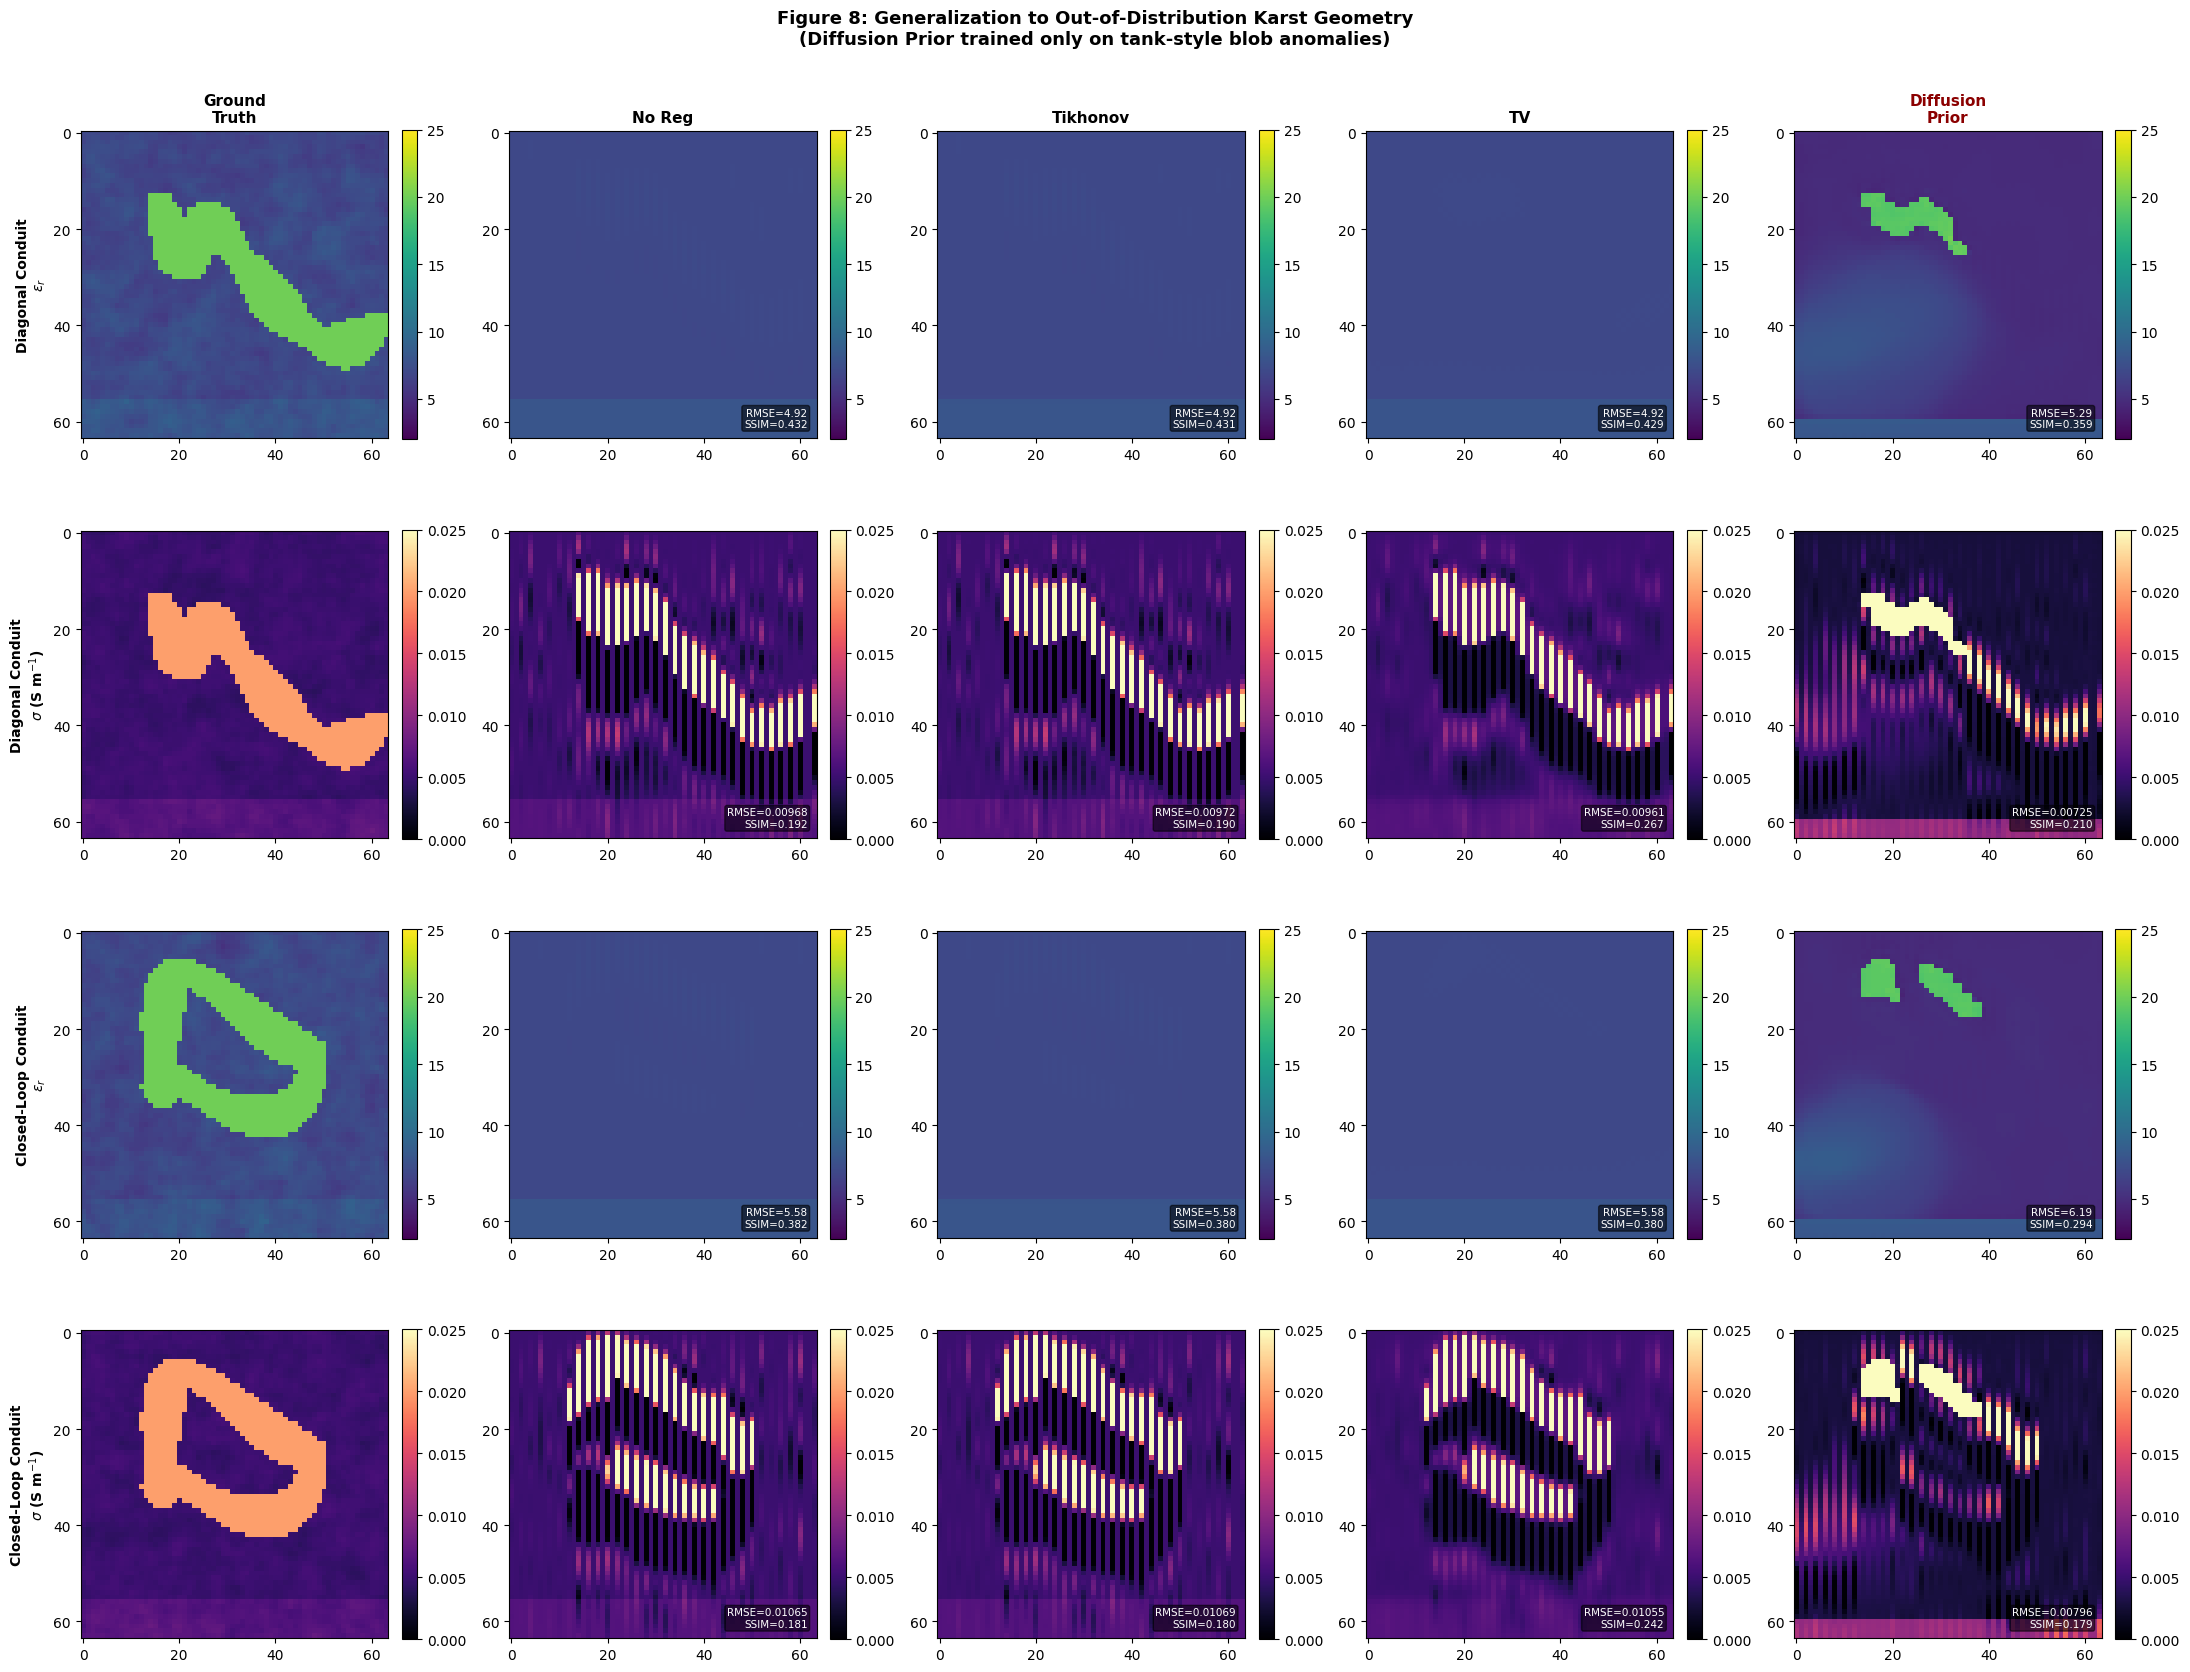

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure 8 (full, both channels) saved at 300 dpi.


In [12]:
fig, axes = plt.subplots(4, 5, figsize=(22, 17))

test_data = [
    ('Diagonal Conduit', eps_karst,  sig_karst,  results_karst,  metrics_karst),
    ('Closed-Loop Conduit', eps_karst2, sig_karst2, results_karst2, metrics_karst2),
]

cols = ['Ground\nTruth', 'No Reg', 'Tikhonov', 'TV', 'Diffusion\nPrior']

for t_idx, (test_name, eps_truth, sig_truth, results, metrics) in enumerate(test_data):
    eps_row = t_idx * 2
    sig_row = t_idx * 2 + 1

    eps_arrays = [eps_truth,
                  results['No Reg'][0], results['Tikhonov'][0],
                  results['TV'][0],     results['Diffusion'][0]]
    sig_arrays = [sig_truth,
                  results['No Reg'][1], results['Tikhonov'][1],
                  results['TV'][1],     results['Diffusion'][1]]

    eps_metrics = ['']
    sig_metrics = ['']
    for m in ['No Reg', 'Tikhonov', 'TV', 'Diffusion']:
        eps_metrics.append(f"RMSE={metrics[m]['eps_rmse']:.2f}\n"
                           f"SSIM={metrics[m]['eps_ssim']:.3f}")
        sig_metrics.append(f"RMSE={metrics[m]['sig_rmse']:.5f}\n"
                           f"SSIM={metrics[m]['sig_ssim']:.3f}")

    for j in range(5):
        ax = axes[eps_row, j]
        im = ax.imshow(eps_arrays[j], cmap='viridis', vmin=2, vmax=25)
        if t_idx == 0:
            ax.set_title(cols[j], fontsize=11, fontweight='bold',
                        color='#8B0000' if j == 4 else 'black')
        ax.set_xticks([0, 20, 40, 60]); ax.set_yticks([0, 20, 40, 60])
        if j == 0:
            ax.set_ylabel(f'{test_name}\n' + r'$\varepsilon_r$',
                          fontsize=10, fontweight='bold')
        if j > 0:
            ax.text(0.97, 0.03, eps_metrics[j], transform=ax.transAxes,
                    fontsize=7.5, ha='right', va='bottom', color='white',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.55))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[sig_row, j]
        im = ax.imshow(sig_arrays[j], cmap='magma', vmin=0, vmax=0.025)
        ax.set_xticks([0, 20, 40, 60]); ax.set_yticks([0, 20, 40, 60])
        if j == 0:
            ax.set_ylabel(f'{test_name}\n' + r'$\sigma$ (S m$^{-1}$)',
                          fontsize=10, fontweight='bold')
        if j > 0:
            ax.text(0.97, 0.03, sig_metrics[j], transform=ax.transAxes,
                    fontsize=7.5, ha='right', va='bottom', color='white',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.55))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Figure 8: Generalization to Out-of-Distribution Karst Geometry\n'
             '(Diffusion Prior trained only on tank-style blob anomalies)',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('figure8_generalization_full.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('figure8_generalization_full.png')
print("Figure 8 (full, both channels) saved at 300 dpi.")